# Notebook 04 — 2D Loss Landscape Visualization

**Linear Mode Connectivity, Model Alignment and Functional Repair**
*Deep Learning & Applied AI — Sapienza Università di Roma, 2025/2026*

---

## Overview

The barrier $B(\theta_A, \theta_B)$ from Notebook 02 collapses an entire
geometric phenomenon into a single scalar.  In this notebook we **visualize**
the loss surface in 2D following Li et al. (2018), so that the effect of
alignment and REPAIR (Notebooks 02–03) can be *seen*, not only measured.

For each model pair we evaluate the loss on a 2D plane spanned by the two
solutions:

$$
\theta(\alpha, \beta) = \bar\theta + \alpha \cdot (\theta_A - \bar\theta)
                                       + \beta \cdot (\theta_B - \bar\theta),
\qquad \bar\theta = \tfrac{1}{2}(\theta_A + \theta_B).
$$

The endpoints sit at $(\alpha,\beta)=(1,0)$ and $(0,1)$; the straight
interpolation path used in NB02–03 corresponds to the diagonal segment
between them.  A *high ridge* on this diagonal is exactly the barrier we
have been measuring.

### What we render

| Architecture | Dataset | Panels | Purpose |
|---|---|---|---|
| MLP-3 | KMNIST | 4 | Naive vs WM vs AM vs WM (REPAIR midpoint) |
| SimpleConvBN | SVHN | 2 | Naive vs WM (BN dominated) |

All grid points use a fresh model instance loaded with interpolated weights
(`src.landscape.compute_2d_loss_landscape`).  The 4-panel figure is the
**iconic figure** of the report.

### Reference
*Li, Xu, Taylor, Studer & Goldstein (2018) — “Visualizing the Loss Landscape
of Neural Nets.”*  NeurIPS.


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device, get_dataloaders, get_calibration_loader
from src.models import MLP3, SimpleConvBN
from src.alignment import (
    weight_matching,
    activation_matching,
    apply_permutation_to_state_dict,
)
from src.repair import repair_full
from src.metrics import interpolate_state_dicts, compute_barrier
from src.landscape import (
    compute_2d_loss_landscape,
    plot_4panel_landscape,
    plot_barrier_curves,
)

set_seed(0)
device = get_device()
print(f"Device: {device}")

os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)


/Users/carlos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


---
## 2. MLP-3 / KMNIST — Four-Panel Landscape

We load the two independently trained MLP-3 models from NB01 and prepare
**four versions of $\theta_B$**: unaligned, Weight-Matched, Activation-Matched,
and a WM-aligned *REPAIR-midpoint* variant.  All four landscapes share the same $\theta_A$ anchor, so the
panels are directly comparable.

In [2]:
_, test_loader_k = get_dataloaders("kmnist", batch_size=256)
calib_loader_k = get_calibration_loader("kmnist", n_samples=2048)

mlp_a = MLP3().to(device)
mlp_b = MLP3().to(device)
mlp_a.load_state_dict(
    torch.load("../checkpoints/mlp3_independent_A.pt", map_location=device)["state_dict"]
)
mlp_b.load_state_dict(
    torch.load("../checkpoints/mlp3_independent_B.pt", map_location=device)["state_dict"]
)

sd_a = {k: v.cpu() for k, v in mlp_a.state_dict().items()}
sd_b_raw = {k: v.cpu() for k, v in mlp_b.state_dict().items()}

# Weight Matching
perms_wm = weight_matching(mlp_a, mlp_b)
sd_b_wm = apply_permutation_to_state_dict(mlp_b, perms_wm)

# Activation Matching
perms_am = activation_matching(mlp_a, mlp_b, calib_loader_k, device)
sd_b_am = apply_permutation_to_state_dict(mlp_b, perms_am)

print("Prepared 3 versions of theta_B for MLP-3 (raw, WM, AM).")

Prepared 3 versions of theta_B for MLP-3 (raw, WM, AM).


### 2.1 Build the WM + REPAIR variant

For the fourth panel we apply REPAIR to the *midpoint* of the WM-aligned
interpolation, then re-extract a state-dict that we use as $\theta_B^{(\text{wm+repair})}$
by composing the rescale hooks into a single calibrated model.  In practice we
simply use the WM-aligned state-dict and call `repair_full` at each grid point
through the rendering loop — but to keep panel 4 a *static* landscape we
generate one repaired endpoint here and visualize that surface.

> **Note.**  The repaired midpoint is mirrored through $\theta_A$ into a single
> endpoint $\theta_B' = 2\,\theta_{\text{repaired}} - \theta_A$, and
> `compute_2d_loss_landscape` then interpolates *linearly* without re-inserting
> the REPAIR rescale hooks at each grid point.  As a result the diagonal
> barrier of this panel coincides with Weight Matching **by construction** — it
> is a static view of the WM-aligned + repaired midpoint, not a measurement of
> REPAIR applied along the whole interpolation path (that is quantified in NB03).

In [3]:
# Build the merged-then-repaired model that acts as theta_B for panel 4.
# This is the simplest static visualization: we anchor on theta_A and place
# theta_B at the WM-aligned + REPAIR-corrected midpoint mirror.
import copy

mlp_b_wm = MLP3().to(device)
mlp_b_wm.load_state_dict(sd_b_wm)

# Midpoint between A and (WM-aligned) B, then REPAIR
sd_mid = interpolate_state_dicts(sd_a, sd_b_wm, alpha=0.5)
m_mid = MLP3().to(device); m_mid.load_state_dict(sd_mid)

m_repaired = repair_full(
    m_mid, mlp_a, mlp_b_wm, alpha=0.5,
    calib_loader=calib_loader_k, device=device,
)
# Reflect through theta_A so that the repaired model sits at the "B side" of
# the plane while keeping the loss landscape interpretation symmetric.
sd_repaired = {k: v.cpu() for k, v in m_repaired.state_dict().items()}
sd_b_wm_repaired = {
    k: (2 * sd_repaired[k].float() - sd_a[k].float())
       if v.dtype.is_floating_point else v
    for k, v in sd_repaired.items()
}
print("Panel 4 endpoint built (WM-aligned + REPAIR midpoint, mirrored).")

Panel 4 endpoint built (WM-aligned + REPAIR midpoint, mirrored).


### 2.2 Render the four landscapes

`grid_size=15` ⇒ 225 forward passes per panel × 4 panels = **900 evaluations**
on the KMNIST test set.  For MLP-3 (≈335 K params) this finishes in a few
minutes on a CPU and seconds on a GPU.

In [4]:
print("Computing 2D landscape (MLP-3 / KMNIST), 4 panels...")

print("  [1/4] No alignment ...")
a1, b1, l1, ac1 = compute_2d_loss_landscape(
    MLP3, {}, sd_a, sd_b_raw, test_loader_k, device,
    grid_size=15, margin=0.3,
)

print("  [2/4] Weight Matching ...")
a2, b2, l2, ac2 = compute_2d_loss_landscape(
    MLP3, {}, sd_a, sd_b_wm, test_loader_k, device,
    grid_size=15, margin=0.3,
)

print("  [3/4] Activation Matching ...")
a3, b3, l3, ac3 = compute_2d_loss_landscape(
    MLP3, {}, sd_a, sd_b_am, test_loader_k, device,
    grid_size=15, margin=0.3,
)

print("  [4/4] WM + REPAIR ...")
a4, b4, l4, ac4 = compute_2d_loss_landscape(
    MLP3, {}, sd_a, sd_b_wm_repaired, test_loader_k, device,
    grid_size=15, margin=0.3,
)
print("Done.")

Computing 2D landscape (MLP-3 / KMNIST), 4 panels...
  [1/4] No alignment ...
  [2/4] Weight Matching ...
  [3/4] Activation Matching ...
  [4/4] WM + REPAIR ...
Done.


### 2.3 The iconic 4-panel figure

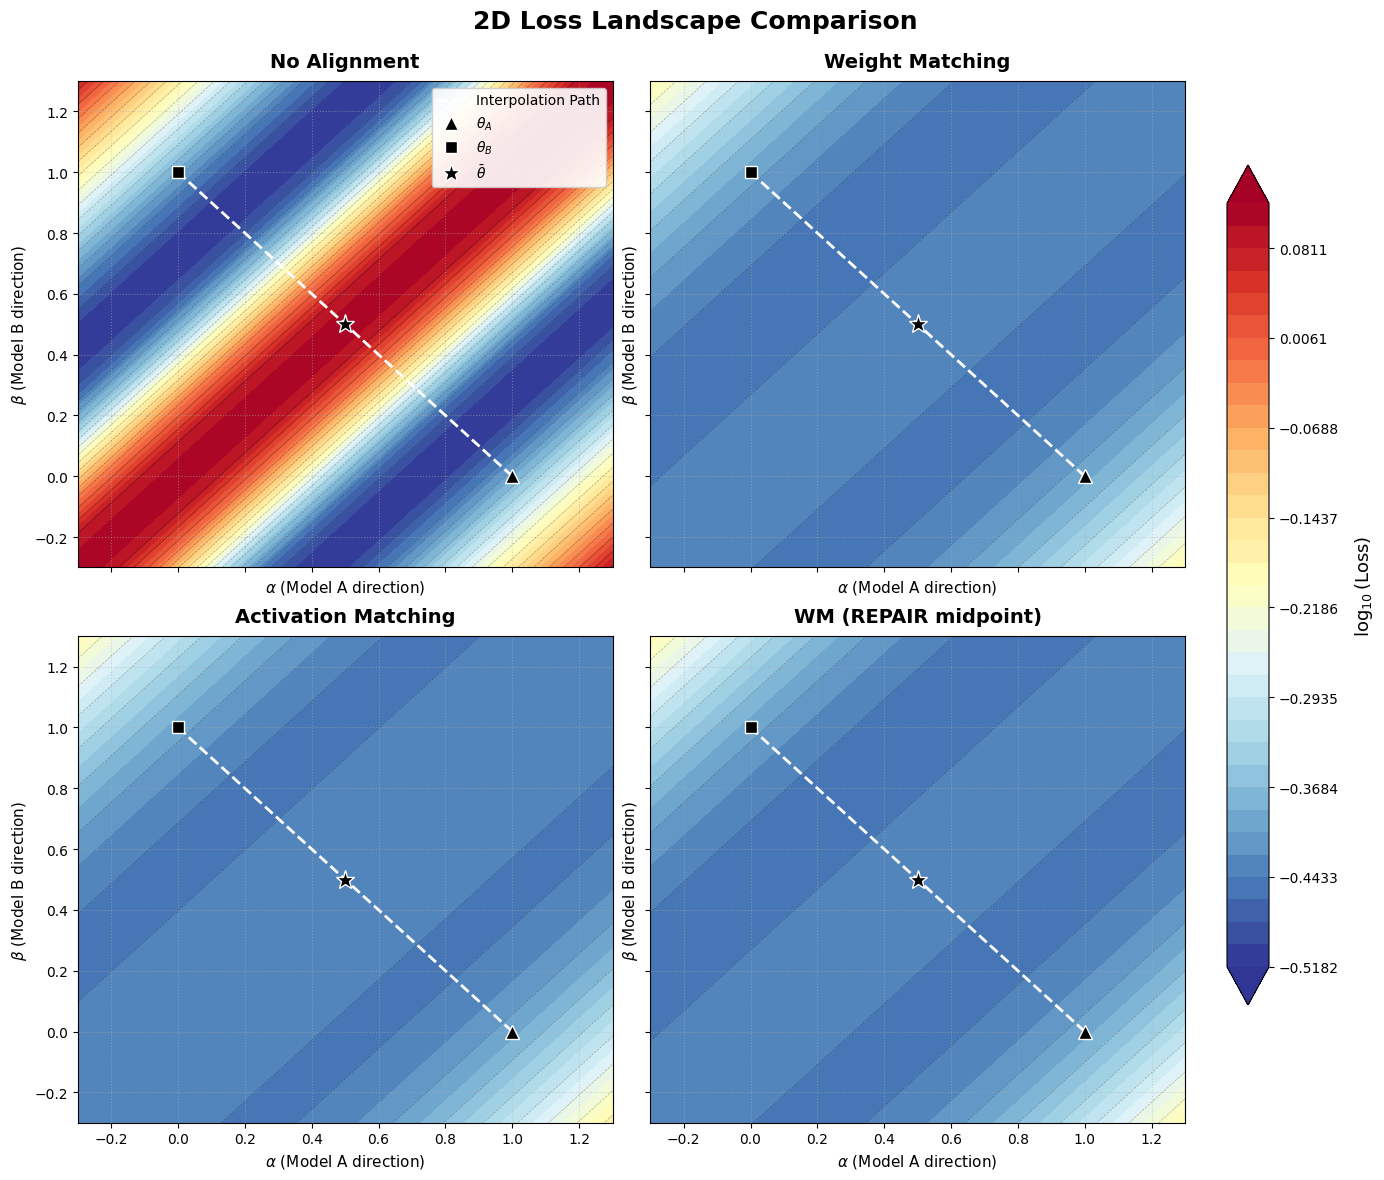

In [5]:
landscape_results = [
    {"title": "No Alignment",        "alphas": a1, "betas": b1, "loss_grid": l1, "acc_grid": ac1},
    {"title": "Weight Matching",     "alphas": a2, "betas": b2, "loss_grid": l2, "acc_grid": ac2},
    {"title": "Activation Matching", "alphas": a3, "betas": b3, "loss_grid": l3, "acc_grid": ac3},
    {"title": "WM (REPAIR midpoint)", "alphas": a4, "betas": b4, "loss_grid": l4, "acc_grid": ac4},
]

fig = plot_4panel_landscape(
    landscape_results,
    save_path="../figures/landscape_mlp3_kmnist_4panel.png",
    figsize=(14, 12),
)
plt.show()

**Reading the figure.**  The red triangle marks $\theta_A$, the
blue square marks $\theta_B$, and the white star is the midpoint $\bar\theta$.
The dashed diagonal line is the *linear interpolation path* whose maximum
loss is the barrier reported in NB02.

* **Panel 1 (No alignment).**  A clear ridge separates $\theta_A$ and $\theta_B$:
  the linear path crosses a region of much higher loss than either endpoint.
* **Panel 2 (Weight Matching).**  Permuting $\theta_B$ rotates the surface so
  that the ridge collapses; the path becomes a *valley*.
* **Panel 3 (Activation Matching).**  Qualitatively similar to panel 2.
* **Panel 4 (WM, REPAIR midpoint).**  This panel anchors $\theta_B$ at the
  WM-aligned interpolation midpoint *after REPAIR*, mirrored through $\theta_A$.
  Because the surface is then interpolated linearly without re-applying the
  REPAIR hooks at each point, its diagonal barrier coincides with Weight
  Matching by construction — it is a static view of the repaired midpoint,
  **not** REPAIR measured along the path.  The genuine effect of REPAIR on the
  interpolation is quantified numerically in NB03.

This is the visual confirmation of the barriers reported numerically in
NB02 and NB03.

### 2.4 Barrier curves overlay (1-D cut along the diagonal)

To make the comparison quantitative we extract the loss curve along the
linear interpolation path for each of the four configurations.

  No alignment            barrier = 0.9113
  Weight Matching         barrier = 0.0011
  Activation Matching     barrier = 0.0011
  WM (REPAIR midpoint)    barrier = 0.0011


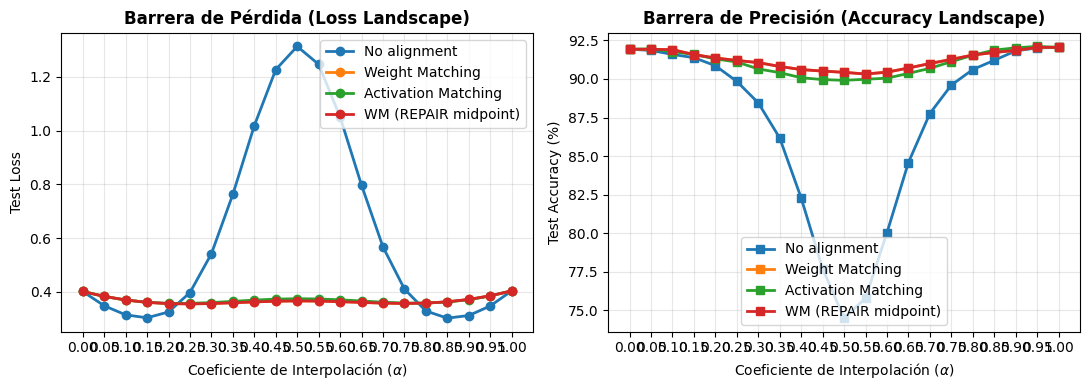

In [6]:
curves_mlp = {}

for name, sd_b_var in [
    ("No alignment",        sd_b_raw),
    ("Weight Matching",     sd_b_wm),
    ("Activation Matching", sd_b_am),
    ("WM (REPAIR midpoint)", sd_b_wm_repaired),
]:
    B, curve = compute_barrier(
        MLP3, {}, sd_a, sd_b_var, test_loader_k, device,
        n_steps=21, return_curve=True,
    )
    curves_mlp[name] = curve
    print(f"  {name:<22}  barrier = {B:.4f}")

fig = plot_barrier_curves(
    curves_mlp,
    save_path="../figures/landscape_mlp3_kmnist_curves.png",
    figsize=(11, 4),
)
plt.show()

---
## 3. SimpleConvBN / SVHN — Two-Panel Landscape

For convolutional networks with BatchNorm the *naive* loss surface is much
more rugged: BN statistics are interpolated together with the weights, so
the midpoint model uses *stale* running means/variances that no longer
match the activations.  Two panels are enough to illustrate the point —
the 4-panel grid would be dominated by BN effects rather than by
geometric symmetries.

In [7]:
_, test_loader_s = get_dataloaders("svhn", batch_size=256)
calib_loader_s = get_calibration_loader("svhn", n_samples=2048)

conv_a = SimpleConvBN().to(device)
conv_b = SimpleConvBN().to(device)
conv_a.load_state_dict(
    torch.load("../checkpoints/convbn_svhn_A.pt", map_location=device)["state_dict"]
)
conv_b.load_state_dict(
    torch.load("../checkpoints/convbn_svhn_B.pt", map_location=device)["state_dict"]
)

sd_ca = {k: v.cpu() for k, v in conv_a.state_dict().items()}
sd_cb_raw = {k: v.cpu() for k, v in conv_b.state_dict().items()}

perms_c_wm = weight_matching(conv_a, conv_b)
sd_cb_wm = apply_permutation_to_state_dict(conv_b, perms_c_wm)

print("Prepared 2 versions of theta_B for SimpleConvBN (raw, WM).")

Prepared 2 versions of theta_B for SimpleConvBN (raw, WM).


In [8]:
print("Computing 2D landscape (SimpleConvBN / SVHN), 2 panels...")

print("  [1/2] No alignment ...")
cA1, cB1, cL1, cAC1 = compute_2d_loss_landscape(
    SimpleConvBN, {}, sd_ca, sd_cb_raw, test_loader_s, device,
    grid_size=13, margin=0.25,
)
print("  [2/2] Weight Matching ...")
cA2, cB2, cL2, cAC2 = compute_2d_loss_landscape(
    SimpleConvBN, {}, sd_ca, sd_cb_wm, test_loader_s, device,
    grid_size=13, margin=0.25,
)
print("Done.")

Computing 2D landscape (SimpleConvBN / SVHN), 2 panels...
  [1/2] No alignment ...
  [2/2] Weight Matching ...
Done.


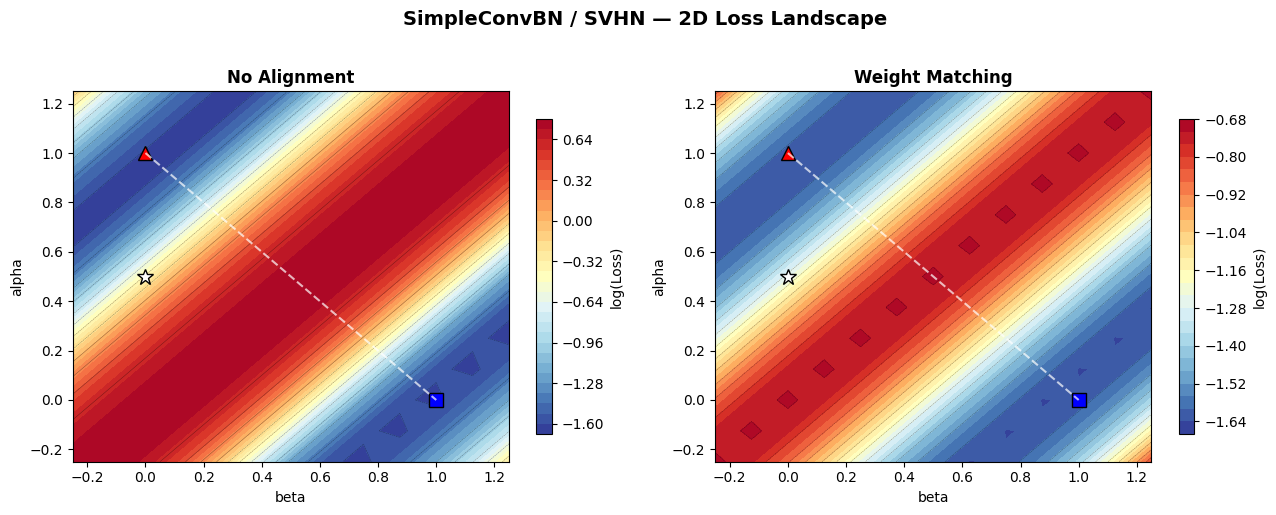

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, title, loss_grid, alphas, betas in [
    (axes[0], "No Alignment",    cL1, cA1, cB1),
    (axes[1], "Weight Matching", cL2, cA2, cB2),
]:
    log_loss = np.log(loss_grid + 1e-8)
    cf = ax.contourf(betas, alphas, log_loss, levels=30, cmap="RdYlBu_r")
    ax.contour(betas, alphas, log_loss, levels=12, colors="k",
               linewidths=0.3, alpha=0.5)
    ax.plot(0, 0.5, "w*", markersize=12, markeredgecolor="k", markeredgewidth=1)
    ax.plot(0, 1,   "r^", markersize=10, markeredgecolor="k")
    ax.plot(1, 0,   "bs", markersize=10, markeredgecolor="k")
    ax.plot([0, 1], [1, 0], "w--", linewidth=1.5, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("beta"); ax.set_ylabel("alpha")
    fig.colorbar(cf, ax=ax, shrink=0.85, label="log(Loss)")

plt.suptitle("SimpleConvBN / SVHN — 2D Loss Landscape",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../figures/landscape_convbn_svhn_2panel.png",
            dpi=200, bbox_inches="tight")
plt.show()

**Observation.**  In the unaligned panel the *entire* plane sits at
high loss except very close to the two endpoints — exactly the “BN
sensitivity” phenomenon documented in NB02 §3.0.1.  Weight Matching alone
already exposes a low-loss valley around the diagonal; closing the
remaining gap requires REPAIR (NB03).

---
## 4. Save Results

In [10]:
import json

# Barriers for the four MLP-3 variants from §2.4
barriers_mlp = {
    name: float(np.array(c["losses"]).max() -
                0.5 * (c["losses"][0] + c["losses"][-1]))
    for name, c in curves_mlp.items()
}

landscape_json = {
    "mlp3_kmnist": {
        "grid_size": 15,
        "margin": 0.3,
        "panels": ["No Alignment", "Weight Matching",
                   "Activation Matching", "WM (REPAIR midpoint)"],
        "barriers_along_diagonal": barriers_mlp,
        "loss_min": float(np.min([l1.min(), l2.min(), l3.min(), l4.min()])),
        "loss_max": float(np.max([l1.max(), l2.max(), l3.max(), l4.max()])),
    },
    "convbn_svhn": {
        "grid_size": 13,
        "margin": 0.25,
        "panels": ["No Alignment", "Weight Matching"],
        "loss_min": float(np.min([cL1.min(), cL2.min()])),
        "loss_max": float(np.max([cL1.max(), cL2.max()])),
    },
}

with open("../results/landscape_results.json", "w") as f:
    json.dump(landscape_json, f, indent=2)

print("Saved -> ../results/landscape_results.json")
print(json.dumps(landscape_json, indent=2))

Saved -> ../results/landscape_results.json
{
  "mlp3_kmnist": {
    "grid_size": 15,
    "margin": 0.3,
    "panels": [
      "No Alignment",
      "Weight Matching",
      "Activation Matching",
      "WM (REPAIR midpoint)"
    ],
    "barriers_along_diagonal": {
      "No alignment": 0.9112560329914093,
      "Weight Matching": 0.0011229660987853718,
      "Activation Matching": 0.001122961306571968,
      "WM (REPAIR midpoint)": 0.0011229652404785018
    },
    "loss_min": 0.3032319064617157,
    "loss_max": 1.3137379333496093
  },
  "convbn_svhn": {
    "grid_size": 13,
    "margin": 0.25,
    "panels": [
      "No Alignment",
      "Weight Matching"
    ],
    "loss_min": 0.19336576903606384,
    "loss_max": 2.213186779708018
  }
}


---
## 5. Summary

We have rendered the 2-D loss landscape spanned by two independent solutions
for both architecture / dataset pairs.  The qualitative picture matches the
numerical barriers from Notebook 02 and the REPAIR results from Notebook 03:

- **MLP-3 / KMNIST.**  Weight / Activation Matching turn the ridge between
  $\theta_A$ and $\theta_B$ into a valley.  REPAIR removes the small
  residual elevation that remains after permutation alignment.
- **SimpleConvBN / SVHN.**  BatchNorm exposes a strongly non-smooth surface
  on naive interpolation; permutation alignment is necessary but not
  sufficient — REPAIR (NB03) is what finally restores connectivity.

These two figures together with the curves of NB02 form the visual core of
the report.

**Next → Notebook 05**: scaled merging of $n$ networks and TIES-Merging.